# Draft

In [67]:
import glob
from pathlib import Path

import ot
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import wasserstein_distance
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.manifold import MDS, TSNE
from sklearn.metrics import pairwise_distances
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram
from sklearn.cluster import KMeans

from src.repartition.data_loading import get_annotation, tif_to_real_mask
from src.repartition.data_analysis import *
from src.repartition.visualization import *
from src.repartition.constants import PROJECT_ROOT, PATH_PATIENT_DATA
from src.repartition.TissueCollection import * 

In [3]:
%load_ext autoreload
%autoreload 1
%aimport src.repartition.data_loading, src.repartition.data_analysis, src.repartition.visualization, src.repartition.constants, src.repartition.TissueCollection

## Load paths

In [4]:
project_root = PROJECT_ROOT
annot_dir = project_root / 'data/repartition/annotation/'
annotations_paths = glob.glob(str(annot_dir) + "/" +'*.tif')
annotations_paths = np.array(annotations_paths)
slides_annot = get_annotation(annotations_paths, tif_to_real_mask)

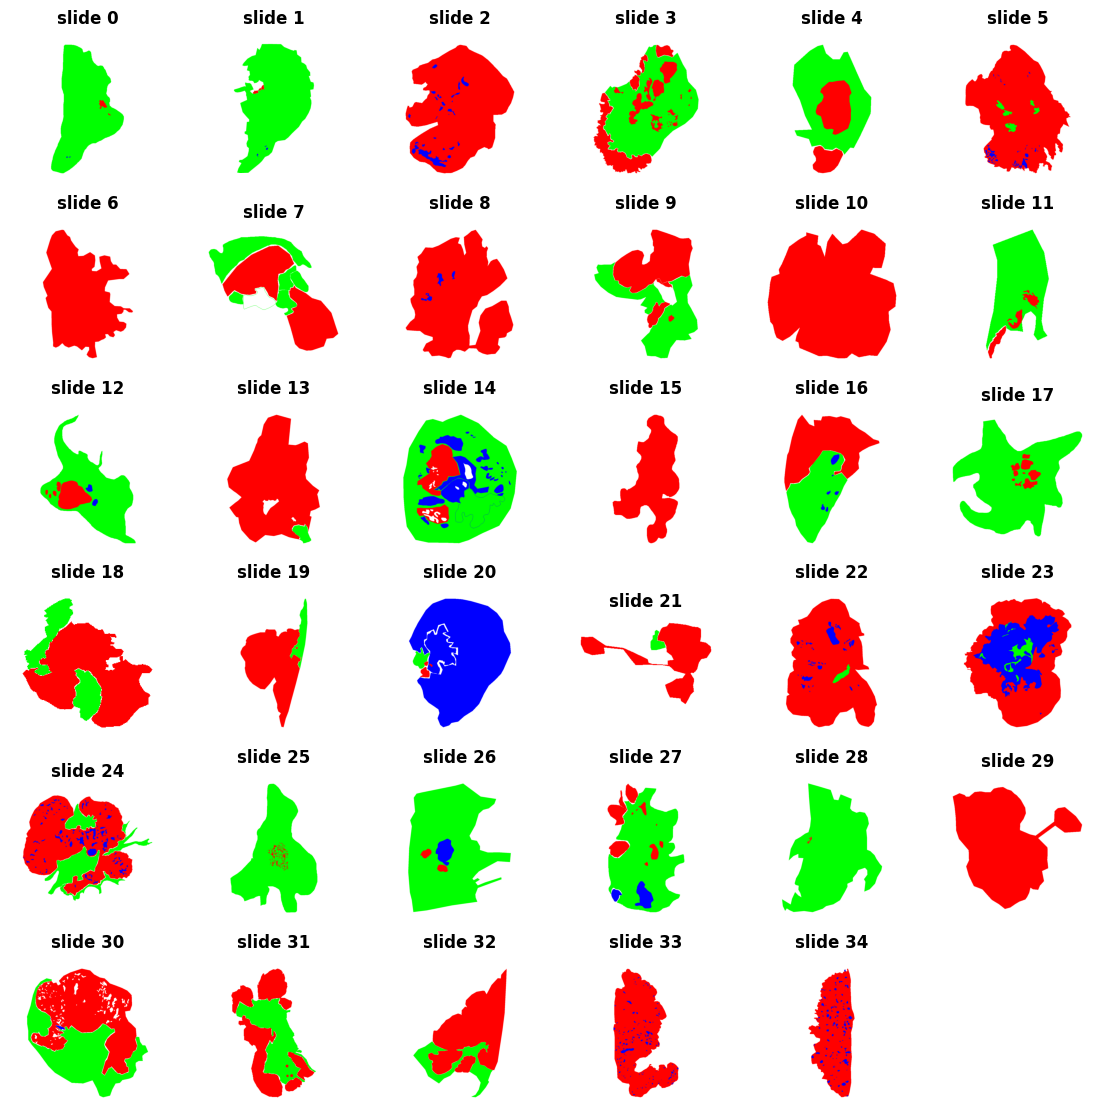

In [5]:
slides_tumor = get_tumor_slides(slides_annot)
plot_slide_grid(slides_tumor)

In [41]:
distance_data, distribution_data_local = get_tissues_data(slides_annot, return_kde=True, local_ratio=True)
#_, distribution_data_global = get_tissues_data(slides_annot, return_kde=True, local_ratio=False)
#distance_data.to_csv('tissues_info.csv')

In [5]:
export_mask_pdf(
    slides_annot,
    output="masks.pdf"
)

In [8]:
export_furthest_tissue_pdf(
    slides_annot, 
    distance_data, 
    tissue_type='tumor',
    output="furthest_tumors.pdf",
    saveimg=True
)

In [174]:
all_tissue_areas = get_areas(distance_data)
export_tissues_proportion(
    all_tissue_areas, 
    draw_type='bar',
    saveimg=True
)

In [9]:
furthest_tum = get_furthest_tumors(distance_data, by='id-slide')
#furthest_tum.to_csv('furthest_tumors.csv')

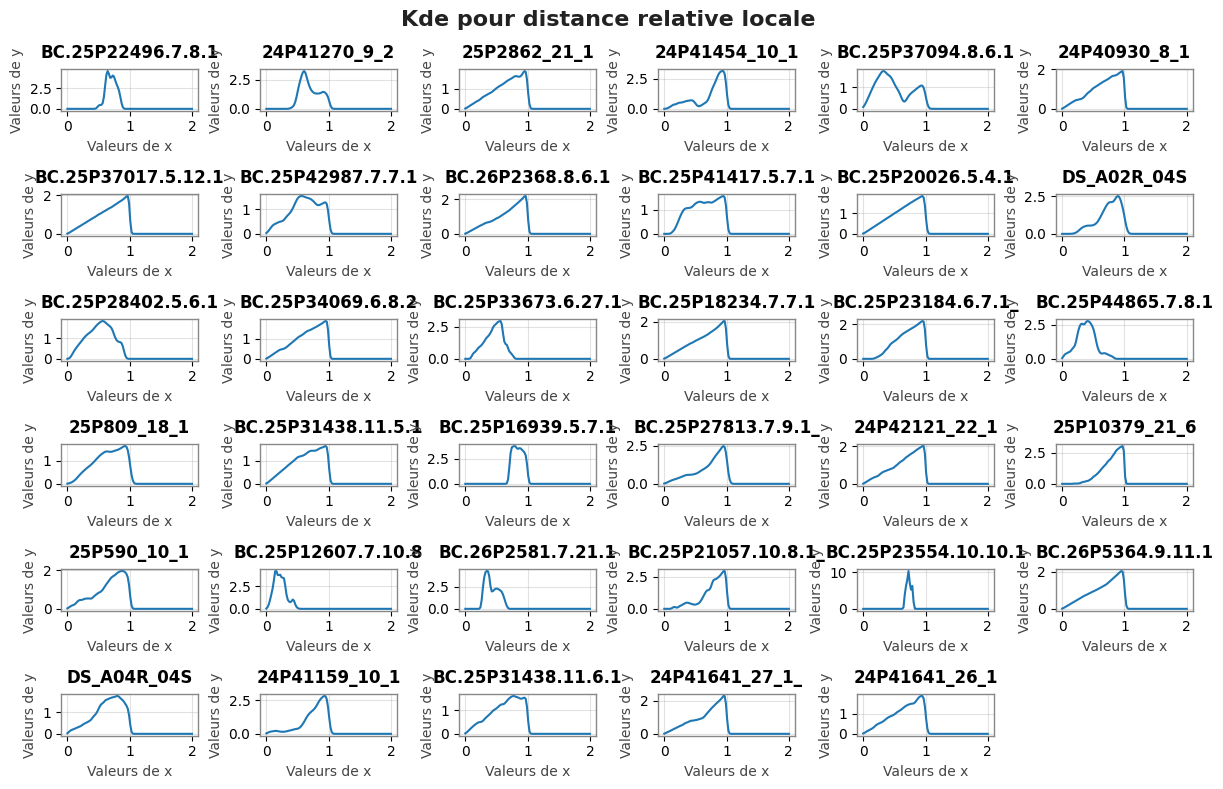

In [12]:
plot_distribution(distribution_data_local, show='kde', ref='center', suptitle="Kde pour distance relative locale")

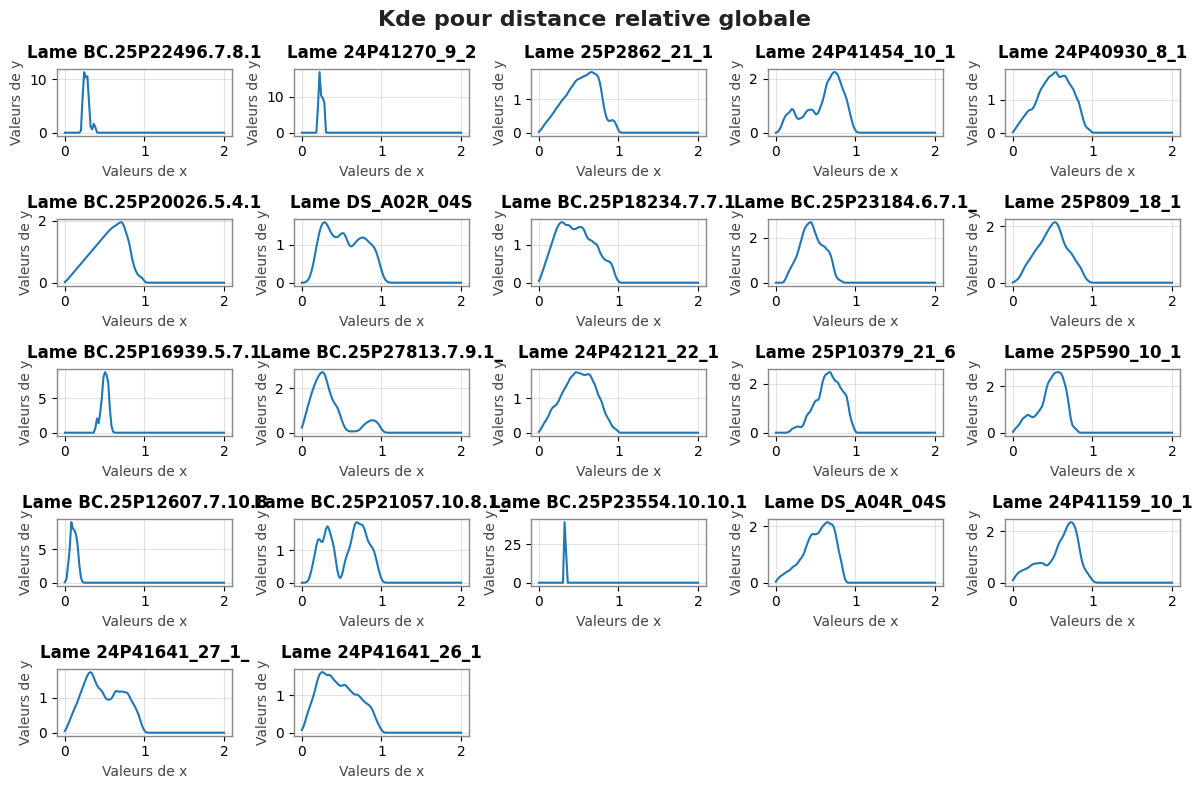

In [ ]:
#plot_distribution(distribution_data_global, show='kde', ref='center', suptitle="Kde pour distance relative globale")

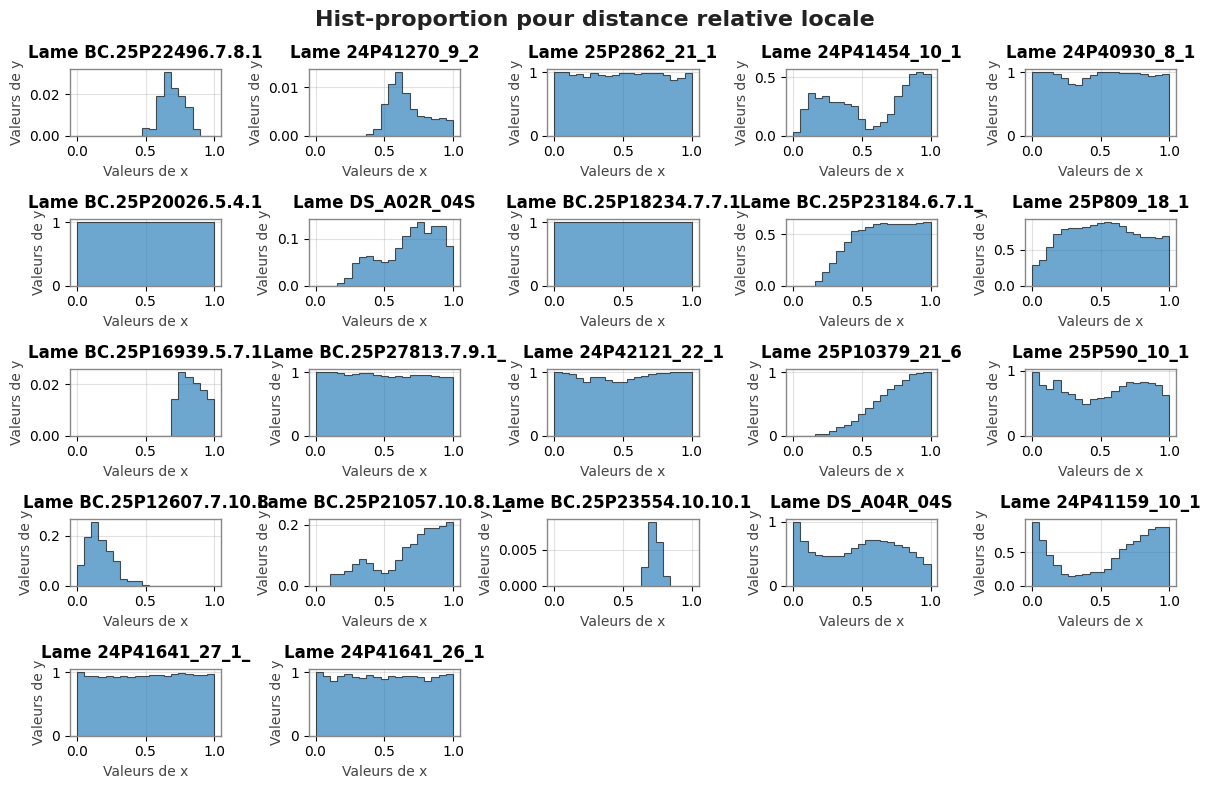

In [104]:
plot_distribution(distribution_data_local, show='hist-proportion', suptitle="Hist-proportion pour distance relative locale")

In [163]:
eval_points = np.linspace(0, 1, 50)
bins = np.linspace(0, 1, 20)
# [0.6, 0, 0.4] ou [0.5, 0, 0.5]
other_w = 0.5
weights = [1-other_w, 0.0, other_w]
kde_vec_local, hist_vec, other_feats = extract_features(
    distribution_data_local, eval_points, 
    bins, distance_data, slides_annot
)

""" kde_vec_global, hist_vec, other_feats = extract_features(distribution_data_global, eval_points, bins,
                                                distance_data=distance_data, slides_annot=slides_annot,
                                                only_distrib=False) """

""" feat2 = extract_features2(slides_annot, [0.1], distance_data)

dist_matrix1 = compute_distance_matrix(
    kde_vec_local, hist_vec, 
    weights, eval_points, bins, 
    additional_feats=feat2
) """

dist_matrix2 = compute_distance_matrix2(
    kde_vec_local, eval_points, 
    other_feats[:, 0], other_feats[:, 1], neighb
)

In [91]:
def mat(feat):
    n = len(feat)
    dist_matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(i+1, n):
            dist_matrix[i, j] = abs(feat[i] - feat[j])**(1/2)

    for i in range(n):
        for j in range(i+1, n):
            dist_matrix[j, i] = dist_matrix[i, j]

    return dist_matrix

In [149]:
neighb = get_center_neighbor_ratio(slides_annot, [0.1])

<Axes: >

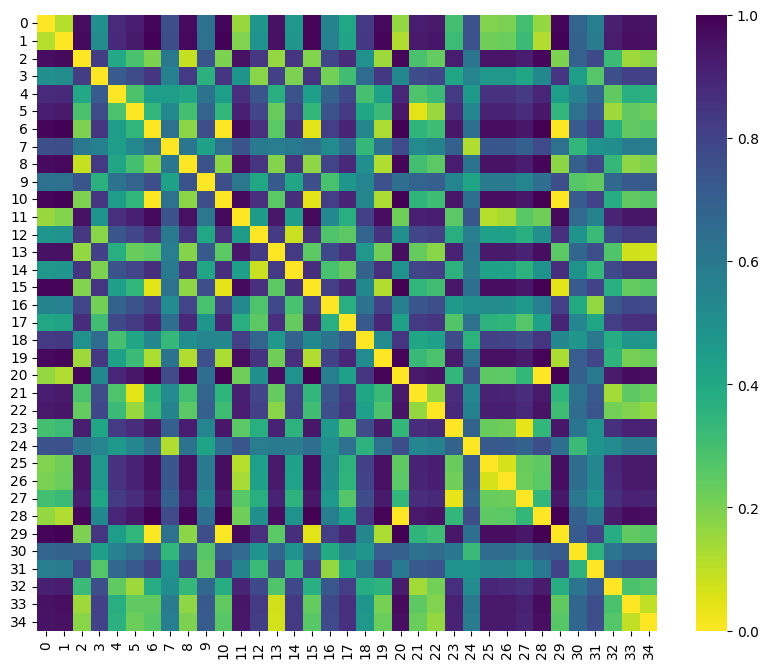

In [141]:
m = mat(neighb)
n = len(m)
plt.figure(figsize=(10, 8))
sns.heatmap(
    m,
    cmap='viridis_r',
    xticklabels=np.arange(n),
    yticklabels=np.arange(n),
)

In [164]:
dist_matrix = dist_matrix2
clustering = AgglomerativeClustering(
    n_clusters=5,
    metric='precomputed',
    linkage='average',           # 'ward' incompatible avec precomputed
)
labels_agglo = clustering.fit_predict(dist_matrix)

clustering = DBSCAN(eps=0.15, min_samples=1, metric='precomputed')
labels_dbscan = clustering.fit_predict(dist_matrix)


mds = MDS(n_components=3, metric='precomputed', random_state=42, n_init=1, init='classical_mds')
X_mds = mds.fit_transform(dist_matrix)

kmeans = KMeans(n_clusters=5, random_state=48, n_init="auto").fit(X_mds)
labels_kmeans = kmeans.predict(X_mds)


tsne = TSNE(n_components=2, metric='precomputed', random_state=42, perplexity=8, init=X_mds)
X_tsne = tsne.fit_transform(dist_matrix)


In [143]:
clustering = AgglomerativeClustering(
    n_clusters=6,
    metric='euclidean',
    linkage='complete'
)
labels_agglo2 = clustering.fit_predict(feat2)

clustering = DBSCAN(eps=0.1, min_samples=1)
labels_dbscan2 = clustering.fit_predict(feat2)


mds = MDS(n_components=2, metric='euclidean', random_state=42, n_init=1, init='classical_mds')
X_mds2 = mds.fit_transform(feat2)

tsne = TSNE(n_components=2, metric='euclidean', random_state=42, perplexity=5, init='pca')
X_tsne2 = tsne.fit_transform(feat2)

NameError: name 'feat2' is not defined

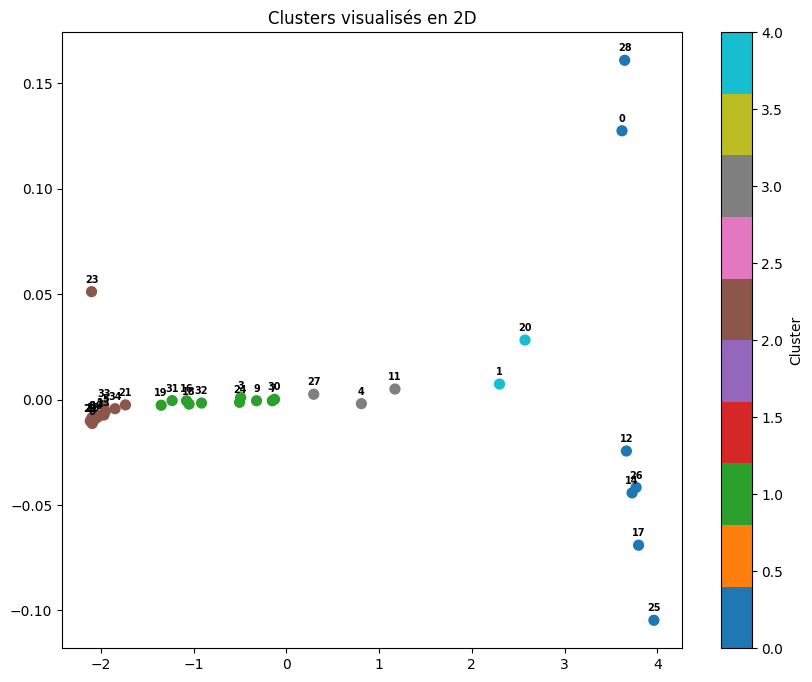

In [166]:
X = X_mds
labels = labels_kmeans

fig, ax = plt.subplots(figsize=(10, 8))

scatter = ax.scatter(X[:, 0], X[:, 1], c=labels, cmap='tab10', s=50)
plt.colorbar(scatter, label='Cluster')

for i, (x, y) in enumerate(X):
    ax.annotate(str(i), (x, y), fontsize=7, fontweight='bold', ha='center', va='bottom',
                xytext=(0, 5), textcoords='offset points')

plt.title('Clusters visualisés en 2D')
plt.show()

In [209]:
from bokeh.plotting import figure, output_notebook, show
from bokeh.models import HoverTool, ColumnDataSource
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

In [210]:
import base64

from bokeh.plotting import figure, output_notebook, show
from bokeh.models import HoverTool, ColumnDataSource, LinearColorMapper, Legend
from bokeh.palettes import Category10_10, Inferno256 

def composite_to_base64_transparent(composite_img, tolerance=20):
    """
    Prend l'image composite NumPy, rend le fond blanc transparent,
    et encode en Base64 PNG pour Bokeh.
    """
    # 1. Conversion en format compatible OpenCV (0-255, uint8)
    # Assumons que make_composite retourne des floats 0-1
    img_uint8 = (composite_img * 255).astype(np.uint8)
    
    # 2. Conversion RGB (Matplotlib) -> BGRA (OpenCV + Alpha)
    img_bgra = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2BGRA)
    
    # 3. Transparence : Masque pour le fond "presque blanc"
    lower_white = 255 - tolerance
    bg_mask = (img_bgra[:, :, 0] >= lower_white) & \
              (img_bgra[:, :, 1] >= lower_white) & \
              (img_bgra[:, :, 2] >= lower_white)
    
    img_bgra[bg_mask, 3] = 0  # Canal Alpha à 0 (transparent)
    
    # 4. Redimensionnement pour la performance de l'infobulle (optionnel)
    img_bgra = cv2.resize(img_bgra, (200, 200), interpolation=cv2.INTER_AREA)

    # 5. Encodage en PNG Base64
    _, buffer = cv2.imencode('.png', img_bgra)
    b64_string = base64.b64encode(buffer).decode('utf-8')
    
    return f"data:image/png;base64,{b64_string}"

# A. Génération des images composites et conversion Base64
b64_images = []
for masks_dict in slides_tumor:
    composite = make_composite(masks_dict)
    b64 = composite_to_base64_transparent(composite, tolerance=30)
    b64_images.append(b64)

# C. Création du DataFrame
df = pd.DataFrame({
    'x': X[:, 0],
    'y': X[:, 1],
    'cluster': labels,
    'cluster_str': labels.astype(str), # Bokeh préfère les chaînes pour les couleurs catégorielles
    'img_data': b64_images
})

# --- 4. Visualisation Bokeh ---

output_notebook()
datasource = ColumnDataSource(df)

# Configuration de la coloration par cluster
# Utilisez Category10_10 si vous avez < 10 clusters, sinon Inferno256
unique_clusters = df['cluster_str'].unique()
palette = Category10_10 if len(unique_clusters) <= 10 else Inferno256
color_mapper = LinearColorMapper(palette=palette, low=df['cluster'].min(), high=df['cluster'].max())

plot = figure(
    title="Visualisation de Clusters d'Images Composites (t-SNE)",
    tools="pan,wheel_zoom,reset,box_zoom,save",
    width=1050,
    height=700,
    background_fill_color="#fafafa"
)

# Dessiner les points (colorés par cluster)
scatter = plot.scatter(
    'x', 'y', 
    source=datasource, 
    size=10, 
    alpha=0.7, 
    # Coloration dynamique :
    fill_color={'field': 'cluster', 'transform': color_mapper},
    line_color=None,
    legend_field='cluster_str',
)

legend = plot.legend[0]
plot.add_layout(legend, 'right')
legend.title = 'Clusters'
legend.click_policy = 'hide'

# Configuration de l'infobulle HTML (avec transparence)
hover = HoverTool(tooltips="""
    <div style="background-color: rgba(255, 255, 255, 0.9); padding: 10px; border-radius: 8px; border: 1px solid #ccc;">
        <div><strong>Cluster:</strong> @cluster</div>
        <div style="margin-top: 5px;">
            <img src="@img_data" alt="Composite preview" style="max-width: 200px; max-height: 200px; display: block; border: 1px solid #eee;">
        </div>
    </div>
""")
plot.add_tools(hover)

show(plot)

NameError: name 'slides_tumor' is not defined

In [244]:
def plot_cluster_grid(slides_tumor, cluster_labels):
    unique_labels = np.unique(cluster_labels)

    for l in unique_labels:
        cluster_slides = [sld for sld, label in zip(slides_tumor, cluster_labels)
                        if label==l]
        plot_slide_grid(cluster_slides, figsize=(8,8), title=f"cluster-{l}")

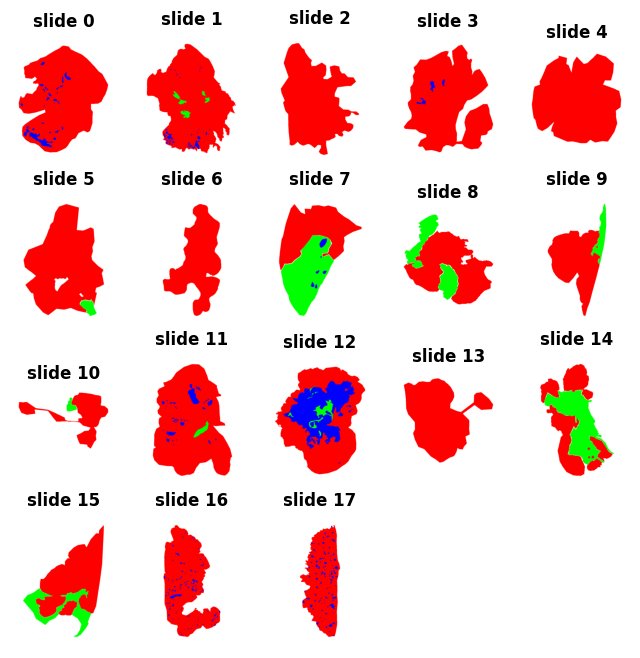

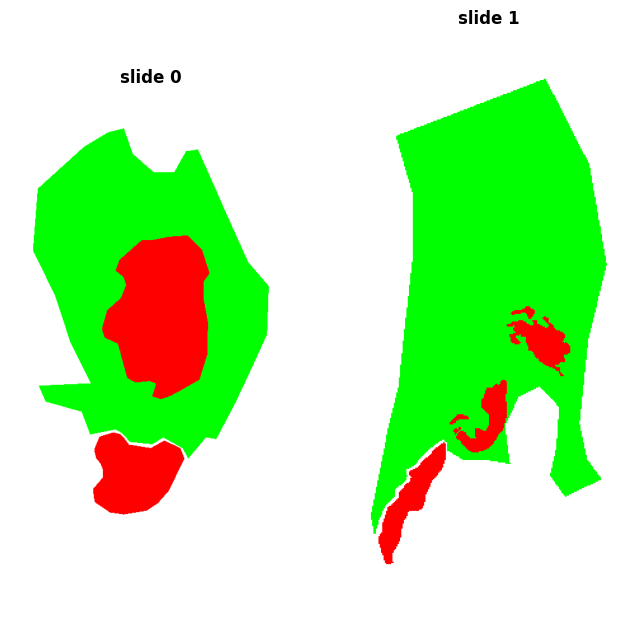

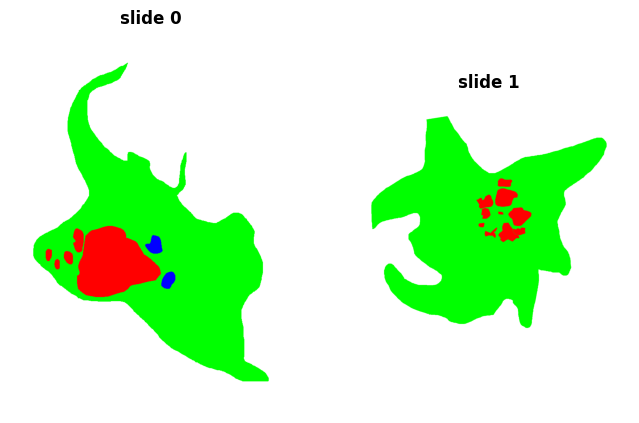

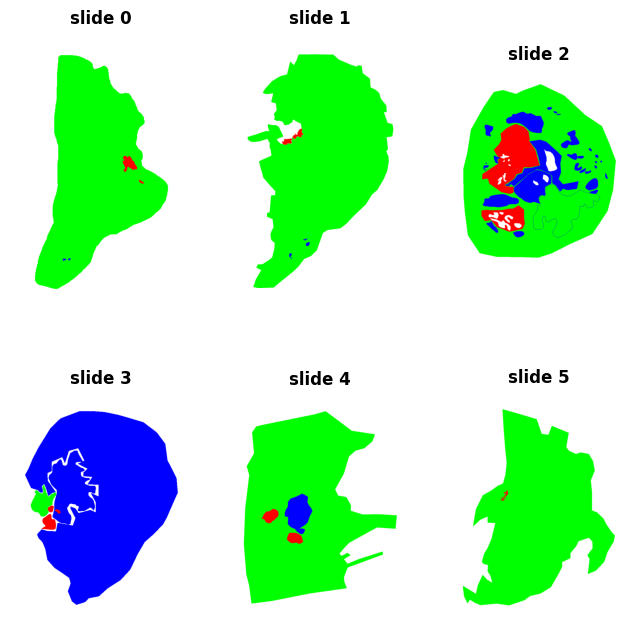

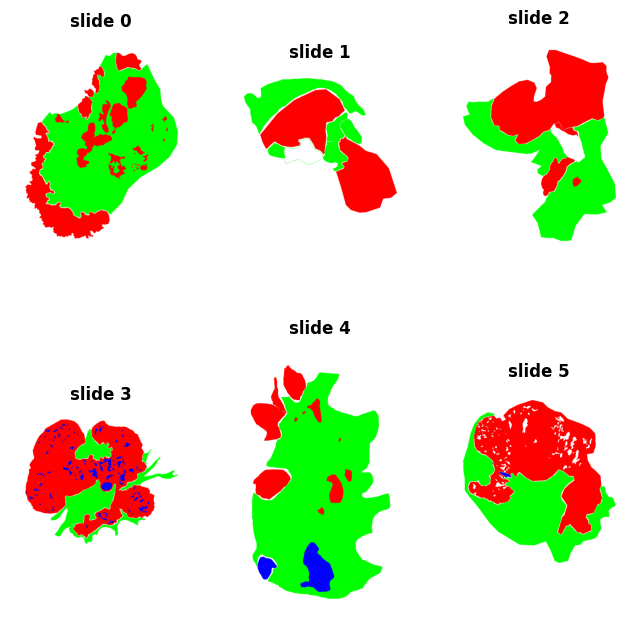

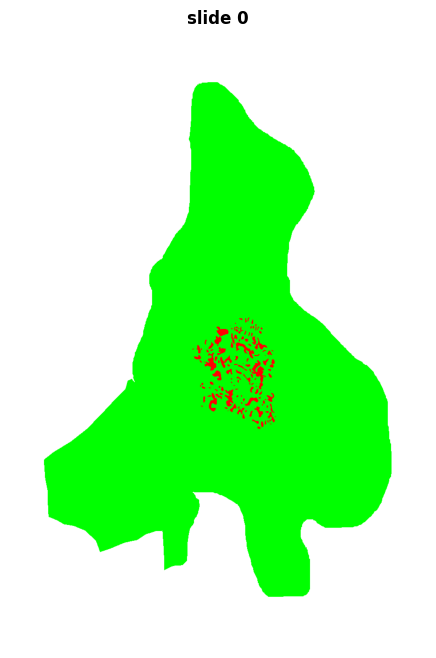

In [245]:
plot_cluster_grid(slides_tumor, labels_agglo2)

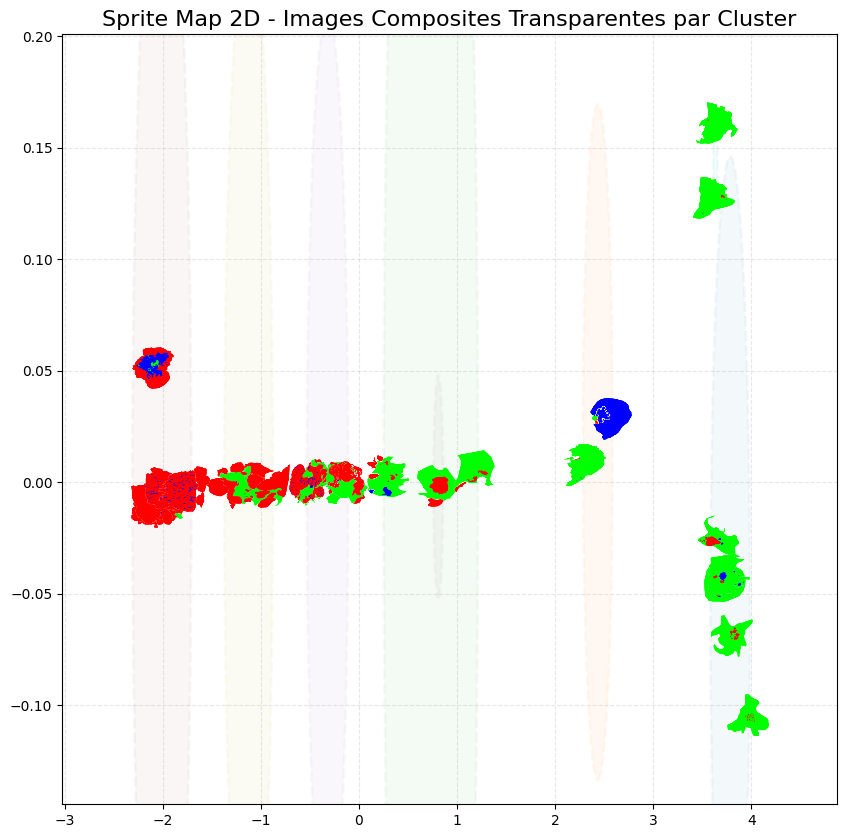

In [249]:
from matplotlib.patches import Circle

def prepare_sprite_image(composite_img, cluster_color, tolerance=30, target_size=(100, 100)):
    img_uint8 = (composite_img * 255).astype(np.uint8)
    img_rgba = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2RGBA)
    
    # Transparence du fond
    lower_white = 255 - tolerance
    bg_mask = (img_rgba[:, :, 0] >= lower_white) & \
              (img_rgba[:, :, 1] >= lower_white) & \
              (img_rgba[:, :, 2] >= lower_white)
    object_mask = ~bg_mask
    
    # On trouve les coordonnées (lignes, colonnes) de tous les pixels non-blancs
    coords = np.argwhere(object_mask)
    
    # Si l'image n'est pas entièrement blanche, on la recadre
    if len(coords) > 0:
        # y_min, x_min = coordonnées minimales / y_max, x_max = coordonnées maximales
        y_min, x_min = coords.min(axis=0)
        y_max, x_max = coords.max(axis=0)
        
        
        # On extrait uniquement la zone contenant l'objet (l'image est "croppée")
        img_rgba = img_rgba[y_min:y_max+1, x_min:x_max+1]
        
        # On doit aussi recalculer le masque de fond pour cette zone recadrée
        bg_mask = bg_mask[y_min:y_max+1, x_min:x_max+1]
    # ----------------------------------

    # 3. Application de la transparence sur la zone recadrée
    img_rgba[bg_mask, 3] = 0
    
    # 4. Redimensionnement strict (l'objet prend maintenant TOUTE la place dans le carré)
    img_rgba = cv2.resize(img_rgba, target_size, interpolation=cv2.INTER_AREA)

    
    return img_rgba

# --- 2. Fonction principale avec Séparation et Gestion du Zoom ---

def plot_sprites_2d_advanced(X_2d, list_of_masks, clusters, zoom=0.5, figsize=(10,10)):

    fig, ax = plt.subplots(figsize=figsize, facecolor='#ffffff')
    
    unique_clusters = sorted(list(set(clusters)))
    cmap = plt.get_cmap('tab10', len(unique_clusters))
    
    cluster_to_color = {}
    for i, cl in enumerate(unique_clusters):
        r, g, b, a = cmap(i)
        cluster_to_color[cl] = (int(r*255), int(g*255), int(b*255), 255)
    
    # 2. SIMULATION DU PAD (set_xlim / set_ylim automatique)
    x_min, x_max = X_2d[:, 0].min(), X_2d[:, 0].max()
    y_min, y_max = X_2d[:, 1].min(), X_2d[:, 1].max()
    
    # Calcul des marges (pad) proportionnelles à la taille du graphique (15% de marge)
    x_pad = (x_max - x_min) * 0.15
    y_pad = (y_max - y_min) * 0.15
    
    ax.set_xlim(x_min - x_pad, x_max + x_pad)
    ax.set_ylim(y_min - y_pad, y_max + y_pad)

    for cl in unique_clusters:
        cluster_points = X_2d[clusters == cl]
        centroid = cluster_points.mean(axis=0)
        radius = np.max(np.linalg.norm(cluster_points - centroid, axis=1)) * 1.1
        radius = 0.05 if radius == 0 else radius
        circle = Circle(centroid, radius, color=np.array(cluster_to_color[cl])/255.0, alpha=0.05, linestyle='--', linewidth=2)
        ax.add_patch(circle)

    for i in range(len(X_2d)):
        x, y = X_2d[i, 0], X_2d[i, 1]
        cl = clusters[i]
        
        composite = make_composite(list_of_masks[i])
        color_rgba = cluster_to_color[cl]
        
        sprite = prepare_sprite_image(composite, color_rgba, target_size=(100, 100))
        
        imagebox = OffsetImage(sprite, zoom=zoom)
        ab = AnnotationBbox(imagebox, (x, y), frameon=False)
        ax.add_artist(ab)

    
    ax.set_title("Sprite Map 2D - Images Composites Transparentes par Cluster", fontsize=16)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.show()

plot_sprites_2d_advanced(X, slides_tumor, labels, zoom=0.3, figsize=(10, 10))

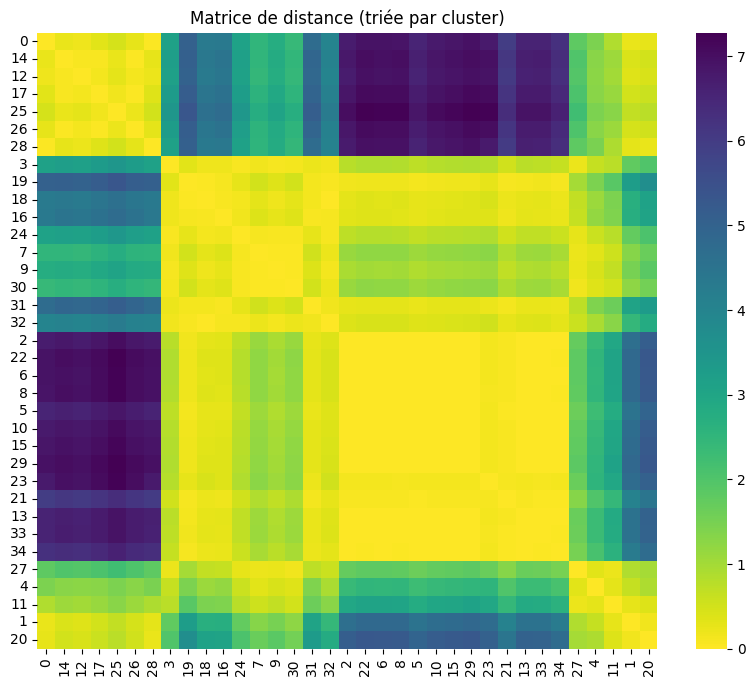

In [38]:
order = np.argsort(labels)
plt.figure(figsize=(10, 8))
sns.heatmap(
    dist_matrix[order][:, order],
    cmap='viridis_r',
    xticklabels=order,
    yticklabels=order
)
plt.title('Matrice de distance (triée par cluster)')

plt.show()

In [251]:
mds.stress_

np.float64(336.0237870913599)

In [ ]:
def plot_dendrogram(model, **kwargs):
    # Create linkage matrix and then plot the dendrogram

    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, **kwargs)

In [ ]:
plot_dendrogram(clustering, truncate_mode="level", p=6)

In [ ]:
dist_2d = pairwise_distances(X)

orig = dist_matrix
proj = mds.dissimilarity_matrix_

plt.scatter(orig, proj, alpha=0.5)
plt.plot([orig.min(), orig.max()], [orig.min(), orig.max()], 'r--')
plt.xlabel("Distances originales")
plt.ylabel("Distances projetées")
plt.title("Shepard plot — idéalement tous les points sur la diagonale")

In [136]:
score = silhouette_score(dist_matrix, labels_agglo, metric='precomputed')
print(f"Silhouette : {score:.3f}")  # Entre -1 et 1, > 0.5 = bons clusters

Silhouette : 0.447


# Processing patient data

In [44]:
raw_data = pd.read_excel(PATH_PATIENT_DATA)

vars_clust = (
    'Patient',
    'Sexe',
    'Tabagisme avant le diagnostic (oui/jamais)',
    'Age au diagnostic',
    'Taille tumorale avant TTT (en mm)',
    'Type histologique',
    'PDL1',
    'cTNM',
    'Type de TTT neoadjuvant',
    'Molecule n°1',
    'Molecule n°2',
    'Molecule n°3',
    'Nombre de cycle de chimio-immunothérapie',
    'Nombre de cycle de maintenance',
    'Delai entre dernier TTT et chirurgie (en j)',
)

vars_desc = (
    'Patient',
    'Type histologique',
    'Stade clinique',
    'Type de chirurgie', 
    'Regression pathologique'
)

data_c = raw_data.loc[:, vars_clust]
data_d = raw_data.loc[:, vars_desc]

data_c['Patient'] = data_c['Patient'].str.strip()
data_d['Patient'] = data_d['Patient'].str.strip()

In [ ]:
data_c

,Patient,Sexe,Tabagisme avant le diagnostic (oui/jamais),Age au diagnostic,Taille tumorale avant TTT (en mm),Type histologique,PDL1,cTNM,Type de TTT neoadjuvant,Molecule n°1,Molecule n°2,Molecule n°3,Nombre de cycle de chimio-immunothérapie,Nombre de cycle de maintenance,Delai entre dernier TTT et chirurgie (en j)
0,24P37162,0.0,1,57,39,1.0,2.0,cT2bN2bM0,0.0,0.0,0,1,3,.,57
1,24P37603,0.0,1,63,41,1.0,1.0,cT2N1M0,0.0,0.0,0,2,4,.,41
2,24P38890,0.0,1,67,22,0.0,0.0,.,1.0,0.0,1,.,3,.,40
3,24P39911,0.0,1,72,15,0.0,2.0,.,0.0,0.0,1,1,3,.,32
4,24P40930,0.0,1,57,54,1.0,0.0,cT2bN2aM0,1.0,0.0,0,.,3,.,36
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,26P5141,0.0,1,65,69,0.0,1.0,cT3N0M0,0.0,0.0,1,1,3,.,7
80,26P5364,0.0,1,54,49,6.0,0.0,cT2bN1M0,0.0,0.0,0,0,4,.,35
81,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,.,NaN
82,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,.,NaN


In [269]:
indices = data_c.index
bad_values = pd.to_numeric(data_c['Delai entre dernier TTT et chirurgie (en j)'], errors='coerce').isna()
len(indices[bad_values] + 2)

14

In [195]:
patient_indices = data_c.loc[:, 'Patient'].dropna().index
data_c = data_c.iloc[patient_indices, :]

In [267]:
data_c['Delai entre dernier TTT et chirurgie (en j)'].unique()

array([57, 41, 40, 32, 36, 539, 63, '.', 42, 43, 25, 10, 27, 97, 46, 62,
       99, 144, 37, 35, 49, 39, 64, 56, 200, 21, 83, 53, '. ', 28, 52, 29,
       33, 133, 48, 31, 44, 82, 76, 80, 54, 89, 30, 7], dtype=object)

In [255]:
vals, count = np.unique(data_c.loc[:, 'Molecule n°2'], return_counts=True)
i = 3
print(f'Total unique values = {len(vals)}')
print(f'nb vals avec effectif < {i}  : {np.sum(count < i)} ~ {np.sum(count < i)/len(vals)}%')

TypeError: '<' not supported between instances of 'int' and 'str'

In [253]:
print(vals, '\n', count)

[ 0.  1. nan] 
 [78  2  1]


In [227]:
np.sum(pd.to_numeric(data_c['Taille tumorale avant TTT (en mm)'], errors='coerce').isna())

np.int64(19)

In [ ]:
def clean_data_clust(df):
    indices = df.index

    df['Patient'] = df['Patient'].str.strip()
    patient_indices = df.loc[:, 'Patient'].dropna().index
    df = df.iloc[patient_indices, :]

    # one-time fix
    bad_values = df.loc[:, 'Tabagisme avant le diagnostic (oui/jamais)'] == '.'
    df.drop(indices[bad_values], inplace=True)

    # one-time fix
    bad_values = df.loc[:, 'Age au diagnostic'] == '.'
    df.drop(indices[bad_values], inplace=True)

    # fix 'Taille tumorale avant TTT (en mm)'

    # fix 'cTNM'

    
    

    

def clean_data_desc(df):
    pass

In [256]:
cols_to_select = [
    'Patient',
    'Type histologique', 'Stade clinique',
    'Type de chirurgie', 'Regression pathologique'
]

data_light = data[cols_to_select]
data_light.dropna(inplace=True)
data_light['Patient'] = data_light['Patient'].str.strip()

In [257]:
tumors = get_furthest_tumors(distance_data, by='id-slide')

In [258]:
tumors = tumors.merge(data_light, how='inner', left_on='id-patient', right_on='Patient')

/tmp/ipykernel_104115/2962698854.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=45, ha='right');


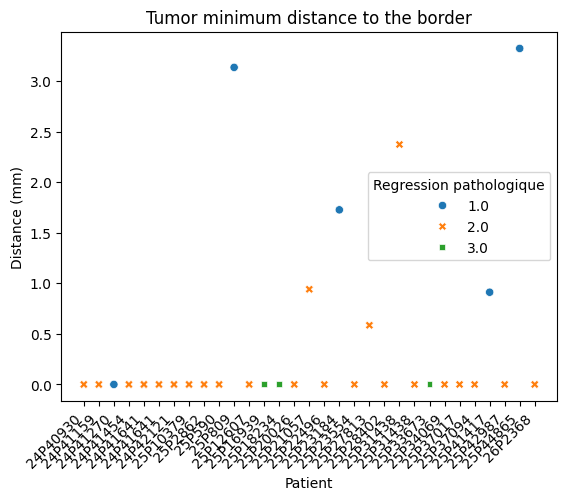

In [259]:
labels = tumors['Patient']
x = np.arange(len(labels))
ax = sns.scatterplot(
    tumors, x='Patient', y='distance-border', 
    hue='Regression pathologique', style='Regression pathologique',
    palette=sns.color_palette(n_colors=3),
)
ax.set_title('Tumor minimum distance to the border')
ax.set_ylabel('Distance (mm)')
ax.set_xticklabels(labels, rotation=45, ha='right');

In [8]:
def get_label_patient(label, distribution_data, data_light):
    df_light = {row['Patient'].strip(): row.drop('Patient').to_dict() for i, row in data_light.iterrows()}
    labels = [df_light[id_patient(sld_name)][label] for sld_name in distribution_data 
              if id_patient(sld_name) in df_light]
    return labels

In [49]:
distribution_data_filtered = {k: v for k, v in distribution_data.items() if id_patient(k) in data_light['Patient'].values}

## Clustering - Optimal Transport

In [260]:
grid = np.linspace(0, 2, 100)
X = np.array([
    dist['kde']['center'](grid) 
    for _, dist in distribution_data_local.items()
])

for row in X:
    row /= row.sum()

X = X.T

Début du clustering...
Convergence atteinte à l'itération 5.


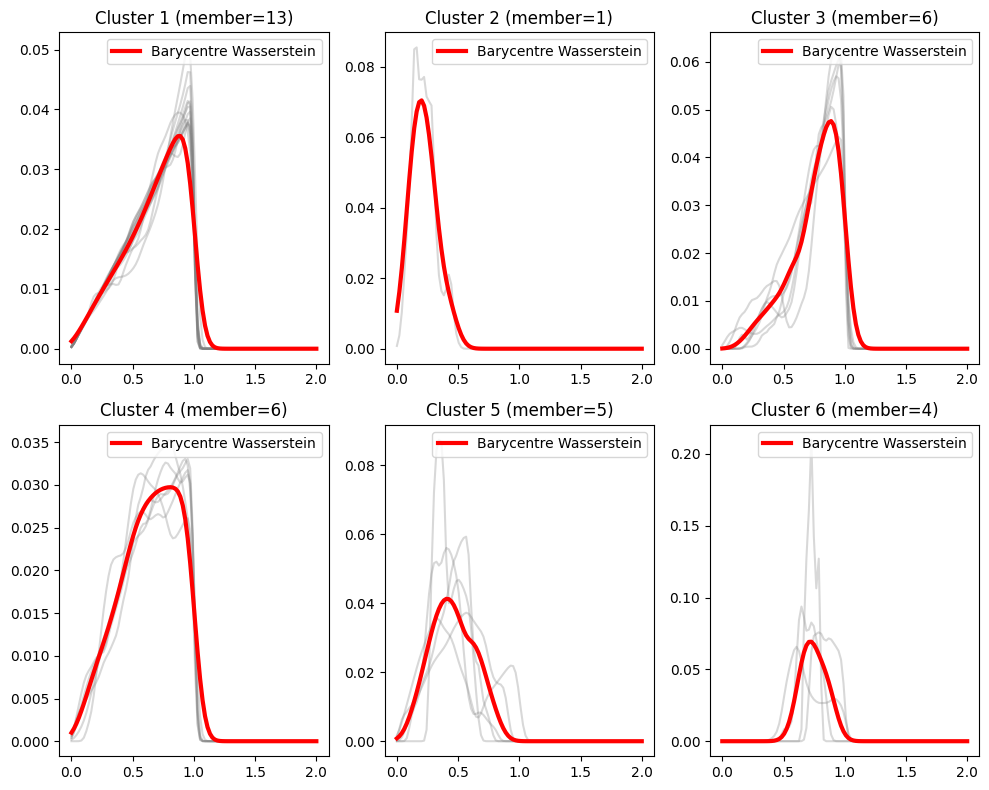

In [ ]:
d, N = X.shape
K = 6                  # Nombre de clusters
max_iter = 50          # Nombre maximum d'itérations
reg = 2e-3             # Paramètre de régularisation entropique (Sinkhorn)
M = ot.dist(grid.reshape((d, 1)), grid.reshape((d, 1)))
M /= np.max(M)
method = 'sinkhorn_log'
# ==========================================
# Algorithme K-Means avec Transport Optimal
# ==========================================
print("Début du clustering...")

init_indices = np.random.choice(N, K, replace=False)
centers = X[:, init_indices].copy()
labels = np.zeros(N)

for iteration in range(max_iter):
    
    # --- ÉTAPE 1 : Assignation ---
    distances = np.zeros((N, K))
    for i in range(N):
        for k in range(K):
            distances[i, k] = ot.sinkhorn2(
                X[:, i], centers[:, k], M, reg, 
                method=method,
            )
            
    new_labels = np.argmin(distances, axis=1)
    
    if np.array_equal(labels, new_labels):
        print(f"Convergence atteinte à l'itération {iteration}.")
        break
    labels = new_labels
    
    # --- ÉTAPE 2 : Mise à jour (Barycentres de Wasserstein) ---
    for k in range(K):
        cluster_data = X[:, labels == k]
        if cluster_data.shape[1] > 0:
            centers[:, k] = ot.bregman.barycenter(
                cluster_data, M, reg,
                method=method
            )

labels_ot_kmeans = labels

# Visualisation
plt.figure(figsize=(10, 8))
cols = math.ceil(math.sqrt(K))
rows = math.ceil(K / cols)
for k in range(K):
    plt.subplot(rows, cols, k+1)
    cluster_data = X[:, labels == k]
    
    # Afficher les distributions du cluster
    for i in range(cluster_data.shape[1]):
        plt.plot(grid, cluster_data[:, i], color='gray', alpha=0.3)
        
    # Afficher le barycentre
    plt.plot(grid, centers[:, k], color='red', linewidth=3, label='Barycentre Wasserstein')
    
    plt.title(f'Cluster {k+1} (member={cluster_data.shape[1]})')
    plt.legend()

plt.tight_layout()
plt.show()

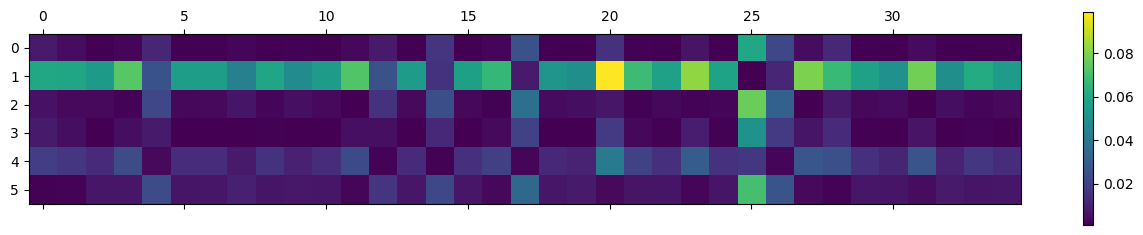

In [262]:
plt.matshow(distances.T)
plt.colorbar()